# NVIDIA SemDeDup with Octen embeddings through vLLM

This notebook implements the staged NVIDIA NeMo Curator 1.3.0 semantic-deduplication workflow: a `Pipeline` creates embeddings with `VLLMEmbeddingModelStage`, `SemanticDeduplicationWorkflow` performs K-means and within-cluster comparisons, and `TextDuplicatesRemovalWorkflow` removes the selected IDs. It calibrates `n_clusters` and `eps` on the 466 annotated pairs without changing the production corpus.

The evaluation is **transductive**: embeddings and unsupervised cluster assignments use all 837 unique texts, while labels are restricted to grouped training folds when selecting parameters. The annotated pairs were enriched by lexical retrieval and labeled by an LLM, so the recommendation is limited to the configurations and panel evaluated here.


In [1]:
from __future__ import annotations

import gc
import hashlib
import importlib.metadata
import json
import os
import platform
import shutil
import time
import unicodedata
from datetime import datetime, timezone
from pathlib import Path

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.model_selection import StratifiedGroupKFold

RUN_COMPUTE = True
SEED = 42
CV_SEED = 20260911
OUTER_SPLITS, OUTER_REPEATS, INNER_SPLITS = 5, 10, 4
CLUSTER_COUNTS = (1, 8, 32)
MODEL_ID = "Octen/Octen-Embedding-8B"
MODEL_REVISION = "5adcfa292e712091dfc30f0e97f0b2282e6cc66c"
EMBEDDING_DIMENSION = 4096
MAX_MODEL_LEN = 32_768
PAIRWISE_BATCH_SIZE = 1024
ATTENTION_BACKEND = "TRITON_ATTN"

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").is_file())
os.chdir(REPO_ROOT)  # Ray's uv runtime hook requires the project root as the worker directory.
ANNOTATION_PATH = REPO_ROOT / "ablations/deduplication/assets/annotations/manual_labels_llm_annotated.csv"
NOTEBOOK_PATH = REPO_ROOT / "ablations/deduplication/semantic/octen_nvidia.ipynb"

def canonical_json(value: object) -> str:
    return json.dumps(value, ensure_ascii=False, sort_keys=True, separators=(",", ":"), allow_nan=False)

def digest(value: object) -> str:
    return hashlib.sha256(canonical_json(value).encode("utf-8")).hexdigest()

def file_sha256(path: Path) -> str:
    checksum = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            checksum.update(chunk)
    return checksum.hexdigest()

def write_json(path: Path, value: object) -> None:
    path.write_text(json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False) + "\n", encoding="utf-8")

VERSIONS = {name: importlib.metadata.version(name) for name in (
    "nemo-curator", "vllm", "torch", "transformers", "numpy",
    "pandas", "pyarrow", "ray", "cuml-cu12", "scikit-learn",
)}
assert VERSIONS["nemo-curator"] == "1.3.0"
SPEC = {
    "protocol": "nvidia-semdedup-octen-vllm-v1",
    "annotation_sha256": file_sha256(ANNOTATION_PATH),
    "model": MODEL_ID, "revision": MODEL_REVISION,
    "representation": "nfkc_question_labeled_choices_with_document_prefix",
    "clusters": CLUSTER_COUNTS, "seed": SEED, "cv_seed": CV_SEED,
    "attention_backend": ATTENTION_BACKEND,
    "outer_splits": OUTER_SPLITS, "outer_repeats": OUTER_REPEATS,
    "inner_splits": INNER_SPLITS, "versions": VERSIONS,
}
RUN_ID = digest(SPEC)[:20]
ARTIFACT_ROOT = REPO_ROOT / "ablations/deduplication/semantic/output/octen_nvidia" / RUN_ID
CACHE_ROOT = ARTIFACT_ROOT / "cache"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_ROOT.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 100)
print(f"Artifacts: {ARTIFACT_ROOT}")
display(pd.Series(VERSIONS, name="version").to_frame())


Artifacts: /home/aluno_paulosantana/repositories/mmlu-pt/ablations/deduplication/semantic/output/octen_nvidia/05ca24295d37f9c51b35


,version
nemo-curator,1.3.0
vllm,0.19.1
torch,2.10.0
transformers,4.57.6
numpy,2.2.6
pandas,2.3.3
pyarrow,25.0.0
ray,2.56.1
cuml-cu12,25.10.0
scikit-learn,1.7.2


## 1. Annotated pairs and stable items

`duplicate` is positive; `related_but_distinct` and `distinct` are negative. Embedding text contains only the question and ordered, labeled choices. Answers, labels, notes, exam names, and sampling metadata are excluded. NFKC and whitespace normalization preserve case, accents, numbers, negation, and choice order. The Octen document prefix `"- "` is added exactly once by the serializer.


In [2]:
columns = ["pair_key", "left_question", "left_choices", "right_question", "right_choices", "label"]
pairs = pd.read_csv(ANNOTATION_PATH, usecols=columns, keep_default_na=False)
assert len(pairs) == pairs.pair_key.nunique() == 466
assert pairs.label.value_counts().to_dict() == {"related_but_distinct": 279, "duplicate": 185, "distinct": 2}

def clean_text(text: str) -> str:
    return " ".join(unicodedata.normalize("NFKC", text).split())

def parse_choices(raw: str) -> list[str]:
    choices = json.loads(raw)
    if not isinstance(choices, list) or not choices or not all(isinstance(choice, str) and choice.strip() for choice in choices):
        raise ValueError("Choices must be a nonempty JSON list of nonempty strings")
    return choices

def labeled_text(question: str, choices: list[str]) -> str:
    alternatives = "\n".join(f"[{chr(65 + index)}] {choice}" for index, choice in enumerate(choices))
    return clean_text(f"{question}\n{alternatives}")

def item_id(question: str, choices: list[str]) -> str:
    return digest(labeled_text(question, choices).casefold())

records: dict[str, dict] = {}
for side in ("left", "right"):
    ids = []
    for question, raw_choices in zip(pairs[f"{side}_question"], pairs[f"{side}_choices"], strict=True):
        choices = parse_choices(raw_choices)
        identifier = item_id(question, choices)
        text = labeled_text(question, choices)
        ids.append(identifier)
        record = {"id": identifier, "question": clean_text(question), "choices": choices, "text": "- " + text}
        if identifier not in records or record["text"] < records[identifier]["text"]:
            records[identifier] = record
    pairs[f"{side}_id"] = ids
items = pd.DataFrame(sorted(records.values(), key=lambda row: row["id"]))
assert len(items) == 837 and items.id.is_unique
assert items.text.str.startswith("- ").all()
item_index = {identifier: index for index, identifier in enumerate(items.id)}
left_index = pairs.left_id.map(item_index).to_numpy()
right_index = pairs.right_id.map(item_index).to_numpy()
labels = pairs.label.eq("duplicate").to_numpy()

parent = {identifier: identifier for identifier in items.id}
def root(identifier: str) -> str:
    while parent[identifier] != identifier:
        parent[identifier] = parent[parent[identifier]]
        identifier = parent[identifier]
    return identifier

def union(left: str, right: str) -> None:
    a, b = sorted((root(left), root(right)))
    parent[b] = a

for left, right in zip(pairs.left_id, pairs.right_id, strict=True):
    union(left, right)
for _, shared in items.groupby(items.question.str.casefold(), sort=True):
    for identifier in shared.id.iloc[1:]:
        union(shared.id.iloc[0], identifier)
pairs["group_id"] = pairs.left_id.map(root)
assert np.array_equal(pairs.group_id, pairs.right_id.map(root))
groups = pairs.group_id.to_numpy()

embedding_input = CACHE_ROOT / "embedding_input"
removal_input = CACHE_ROOT / "removal_input"
embedding_input.mkdir(exist_ok=True)
removal_input.mkdir(exist_ok=True)
items[["id", "text"]].to_parquet(embedding_input / "items.parquet", index=False)
items[["id", "question", "choices"]].to_parquet(removal_input / "items.parquet", index=False)
display(pairs.label.value_counts().rename_axis("label").to_frame("pairs"))
print(f"{len(items)} items; {pairs.group_id.nunique()} evaluation groups")


,pairs
label,
related_but_distinct,279
duplicate,185
distinct,2


837 items; 373 evaluation groups


## 2. Embeddings with `VLLMEmbeddingModelStage`

NeMo Curator 1.3.0 passes `truncate_prompt_tokens` through `tokenization_kwargs`. vLLM 0.19.1 consumes that setting in its renderer, so the official `VLLMEmbeddingModelStage` can be used directly with `pretokenize=False`. The model snapshot is resolved and checked before the pipeline, then Hugging Face access is switched to offline mode so the worker loads the same cached revision.

The settings follow NVIDIA's advanced configuration pattern, adapted to Octen: pooling runner, BF16, 32,768-token context, one GPU, eager execution, and no character truncation. `gpu_memory_utilization` controls vLLM's reservation only; it does not alter model outputs. `TRITON_ATTN` is selected explicitly because this host has no CUDA toolkit for FlashInfer's runtime JIT compilation.


In [3]:
from huggingface_hub import snapshot_download
from nemo_curator.backends.xenna import XennaExecutor
from nemo_curator.core.client import RayClient
from nemo_curator.pipeline import Pipeline
from nemo_curator.stages.text.embedders.vllm import VLLMEmbeddingModelStage
from nemo_curator.stages.text.io.reader.parquet import ParquetReader
from nemo_curator.stages.text.io.writer.parquet import ParquetWriter

MODEL_SNAPSHOT = Path(snapshot_download(MODEL_ID, revision=MODEL_REVISION)).resolve()
assert MODEL_SNAPSHOT.name == MODEL_REVISION
os.environ["HF_HUB_OFFLINE"] = "1"
assert Path(snapshot_download(MODEL_ID, local_files_only=True)).resolve() == MODEL_SNAPSHOT

def parquet_files(directory: Path) -> pd.DataFrame:
    paths = sorted(directory.rglob("*.parquet"))
    frames = []
    for path in paths:
        try:
            frames.append(pd.read_parquet(path))
        except TypeError as error:
            if "[pyarrow]' not understood" not in str(error):
                raise
            frames.append(pd.read_parquet(path, dtype_backend="pyarrow"))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

embedding_output = CACHE_ROOT / "vllm_embeddings"
embedding_complete = CACHE_ROOT / "vllm_embeddings_complete.json"
if not embedding_complete.exists():
    if not RUN_COMPUTE:
        raise FileNotFoundError("Missing vLLM embedding cache")
    if embedding_output.exists():
        shutil.rmtree(embedding_output)
    embedding_stage = VLLMEmbeddingModelStage(
        model_identifier=MODEL_ID, text_field="text", embedding_field="embeddings",
        pretokenize=False, max_chars=None, verbose=False,
        vllm_init_kwargs={
            "runner": "pooling", "convert": "embed", "dtype": "bfloat16",
            "max_model_len": MAX_MODEL_LEN, "tensor_parallel_size": 1, "seed": SEED,
            "enforce_eager": True, "gpu_memory_utilization": 0.3,
            "attention_config": {"backend": ATTENTION_BACKEND},
        },
    )
    embedding_pipeline = Pipeline(
        name="octen_vllm_embeddings", description="Embed annotated MCQA items with Octen through vLLM",
        stages=[
            ParquetReader(file_paths=str(embedding_input), files_per_partition=1, fields=["id", "text"]),
            embedding_stage,
            ParquetWriter(path=str(embedding_output), fields=["id", "embeddings"], mode="overwrite", write_kwargs={"index": False}),
        ],
    )
    embedding_started = time.perf_counter()
    with RayClient(num_gpus=1, num_cpus=8, include_dashboard=False, object_store_memory=2 * 1024**3):
        embedding_pipeline.run(executor=XennaExecutor())
    embedding_seconds = time.perf_counter() - embedding_started
else:
    embedding_seconds = json.loads(embedding_complete.read_text())["seconds"]
print(f"vLLM embedding time: {embedding_seconds:.2f}s")


Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

vLLM embedding time: 113.86s


In [4]:
embedded = parquet_files(embedding_output)
assert len(embedded) == len(items) and embedded.id.is_unique and set(embedded.id) == set(items.id)
embedded = embedded.set_index("id").loc[items.id].reset_index()
embeddings = np.vstack(embedded.embeddings.map(lambda value: np.asarray(value, dtype=np.float32)))
norms = np.linalg.norm(embeddings, axis=1)
assert embeddings.shape == (len(items), EMBEDDING_DIMENSION)
assert np.isfinite(embeddings).all()
assert np.allclose(norms, 1.0, atol=2e-3), (float(norms.min()), float(norms.max()))

pooling_config = json.loads((MODEL_SNAPSHOT / "1_Pooling/config.json").read_text(encoding="utf-8"))
normalization_config = json.loads((MODEL_SNAPSHOT / "2_Normalize/config.json").read_text(encoding="utf-8"))
assert pooling_config["pooling_mode_lasttoken"] is True
assert not any(pooling_config[key] for key in (
    "pooling_mode_cls_token", "pooling_mode_mean_tokens", "pooling_mode_max_tokens",
    "pooling_mode_mean_sqrt_len_tokens", "pooling_mode_weightedmean_tokens",
))
assert normalization_config["normalize_embeddings"] is True

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_SNAPSHOT, local_files_only=True)
token_lengths = []
for start in range(0, len(items), 64):
    encoded = tokenizer(items.text.iloc[start:start + 64].tolist(), truncation=False, padding=False, verbose=False)
    token_lengths.extend(map(len, encoded["input_ids"]))
token_audit = pd.DataFrame({"id": items.id, "tokens": token_lengths})
token_audit["truncated"] = token_audit.tokens > MAX_MODEL_LEN
assert not token_audit.truncated.any()

embedding_hashes = {path.name: file_sha256(path) for path in sorted(embedding_output.rglob("*.parquet"))}
embedding_info = {
    "model": MODEL_ID, "revision": MODEL_REVISION, "snapshot": str(MODEL_SNAPSHOT),
    "stage": "VLLMEmbeddingModelStage",
    "pretokenize": False, "max_chars": None, "runner": "pooling",
    "attention_backend": ATTENTION_BACKEND,
    "pooling": "last_token", "normalized": True, "dtype": "bfloat16",
    "dimension": EMBEDDING_DIMENSION, "max_model_len": MAX_MODEL_LEN,
    "seconds": embedding_seconds, "files_sha256": embedding_hashes,
    "norm_min": float(norms.min()), "norm_max": float(norms.max()),
    "max_tokens_observed": int(token_audit.tokens.max()),
}
write_json(embedding_complete, embedding_info)
del tokenizer
gc.collect()
display(pd.Series(embedding_info).to_frame("value"))


,value
model,Octen/Octen-Embedding-8B
revision,5adcfa292e712091dfc30f0e97f0b2282e6cc66c
snapshot,/raid/aluno_paulosantana/cache/hf/hub/models--Octen--Octen-Embedding-8B/snapshots/5adcfa292e7120...
stage,VLLMEmbeddingModelStage
pretokenize,False
max_chars,None
runner,pooling
attention_backend,TRITON_ATTN
pooling,last_token
normalized,True


## 3. NVIDIA K-means and pairwise similarity

Each candidate uses `SemanticDeduplicationWorkflow` with `eps=None`, retaining intermediate similarities for calibration. K-means fits all 837 embeddings (`fit_data_fraction=None`) because this panel is small; NVIDIA's 10% example targets much larger corpora. `hard` ranks points farthest from their centroid first. One cluster is the global-comparison control.


In [5]:
import ray
from nemo_curator.backends.ray_actor_pool import RayActorPoolExecutor
from nemo_curator.core.client import RayClient
from nemo_curator.stages.deduplication.semantic import SemanticDeduplicationWorkflow

nemo_root = CACHE_ROOT / "nemo_candidates"
nemo_root.mkdir(exist_ok=True)
pending = [count for count in CLUSTER_COUNTS if not (nemo_root / f"k{count}/complete.json").exists()]
if pending:
    if not RUN_COMPUTE:
        raise FileNotFoundError(f"Missing NeMo runs: {pending}")
    if ray.is_initialized() or os.environ.get("RAY_ADDRESS"):
        raise RuntimeError("Close the existing Ray session before this isolated experiment")
    with RayClient(num_gpus=1, num_cpus=8, include_dashboard=False, object_store_memory=2 * 1024**3):
        for count in pending:
            run_dir = nemo_root / f"k{count}"
            started = time.perf_counter()
            workflow = SemanticDeduplicationWorkflow(
                input_path=str(embedding_output), output_path=str(run_dir / "results"),
                cache_path=str(run_dir / "cache"), n_clusters=count,
                id_field="id", embedding_field="embeddings", embedding_dim=EMBEDDING_DIMENSION,
                input_filetype="parquet", max_iter=300, tol=1e-4, random_state=SEED,
                fit_data_fraction=None, distance_metric="cosine", which_to_keep="hard",
                pairwise_batch_size=PAIRWISE_BATCH_SIZE, eps=None, verbose=False,
            )
            workflow.run(kmeans_executor=RayActorPoolExecutor(), pairwise_executor=XennaExecutor())
            write_json(run_dir / "complete.json", {"n_clusters": count, "seconds": time.perf_counter() - started})

pair_cosine = np.clip(np.einsum("ij,ij->i", embeddings[left_index], embeddings[right_index]), -1, 1).astype(float)
candidate_masks: dict[int, np.ndarray] = {}
cluster_rows = []
for count in CLUSTER_COUNTS:
    run_dir = nemo_root / f"k{count}"
    clusters = pd.read_parquet(run_dir / "cache/kmeans_results")
    relations = parquet_files(run_dir / "cache/pairwise_results")
    assert len(clusters) == len(items) and clusters.id.nunique() == len(items)
    assert set(clusters.id) == set(items.id)
    assert len(relations) == len(items) and relations.id.nunique() == len(items)
    assignments = clusters.set_index("id").centroid
    same_cluster = pairs.left_id.map(assignments).eq(pairs.right_id.map(assignments)).to_numpy()
    candidate_masks[count] = same_cluster
    timing = json.loads((run_dir / "complete.json").read_text())
    cluster_rows.append({
        "n_clusters": count, "positive_pairs_split": int(np.sum(labels & ~same_cluster)),
        "positive_pair_cluster_recall": float(np.mean(same_cluster[labels])),
        "candidate_pairs": int(same_cluster.sum()), "seconds": timing["seconds"],
    })
if not candidate_masks[1].all():
    raise AssertionError("n_clusters=1 must compare every annotated pair globally")
cluster_diagnostics = pd.DataFrame(cluster_rows)
cluster_diagnostics.to_csv(ARTIFACT_ROOT / "cluster_diagnostics.csv", index=False)
display(cluster_diagnostics)


,n_clusters,positive_pairs_split,positive_pair_cluster_recall,candidate_pairs,seconds
0,1,0,1.0,466,84.949832
1,8,0,1.0,452,73.154550
2,32,0,1.0,454,65.725082


## 4. Nested grouped calibration

A prediction is positive only when both items share a cluster and their direct cosine is at least `1 - eps`. Inner folds select `n_clusters` by mean MCC and fit the threshold using training labels only. Ties favor precision, recall, fewer clusters, and a higher threshold. Connected pairs and identical normalized questions remain in the same group, preventing shared items across training and validation.


In [6]:
def metrics(expected: np.ndarray, predicted: np.ndarray) -> dict:
    expected, predicted = np.asarray(expected, dtype=bool), np.asarray(predicted, dtype=bool)
    tp = int(np.sum(expected & predicted))
    fp = int(np.sum(~expected & predicted))
    tn = int(np.sum(~expected & ~predicted))
    fn = int(np.sum(expected & ~predicted))
    denominator = float((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
    return {
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "precision": tp / (tp + fp) if tp + fp else np.nan,
        "recall": tp / (tp + fn) if tp + fn else np.nan,
        "f1": 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0,
        "mcc": (tp * tn - fp * fn) / denominator if denominator else 0.0,
    }

def assert_disjoint(train: np.ndarray, test: np.ndarray) -> None:
    assert not set(groups[train]) & set(groups[test])
    train_items = set(pairs.iloc[train].left_id) | set(pairs.iloc[train].right_id)
    test_items = set(pairs.iloc[test].left_id) | set(pairs.iloc[test].right_id)
    assert not train_items & test_items

def threshold_grid(values: np.ndarray, eligible: np.ndarray) -> np.ndarray:
    unique = np.unique(values[eligible])
    if not len(unique):
        return np.array([np.inf])
    return np.r_[
        np.nextafter(unique[0], -np.inf),
        (unique[:-1] + unique[1:]) / 2,
        np.nextafter(unique[-1], np.inf),
    ]

def best_threshold(values: np.ndarray, eligible: np.ndarray, expected: np.ndarray) -> float:
    thresholds = threshold_grid(values, eligible)
    predictions = eligible[None, :] & (values[None, :] >= thresholds[:, None])
    tp = np.sum(predictions & expected, axis=1).astype(float)
    fp = np.sum(predictions & ~expected, axis=1).astype(float)
    fn, tn = expected.sum() - tp, (~expected).sum() - fp
    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = np.divide(tp * tn - fp * fn, denominator, out=np.zeros_like(tp), where=denominator != 0)
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
    recall = np.divide(tp, expected.sum(), out=np.zeros_like(tp), where=expected.sum() != 0)
    index = np.lexsort((thresholds, recall, precision, mcc))[-1]
    return float(thresholds[index])

def select_configuration(indices: np.ndarray, seed: int) -> tuple[int, float, pd.DataFrame]:
    splitter = StratifiedGroupKFold(INNER_SPLITS, shuffle=True, random_state=seed)
    rows = []
    for fold, (train_local, validation_local) in enumerate(splitter.split(indices, labels[indices], groups[indices])):
        train, validation = indices[train_local], indices[validation_local]
        assert_disjoint(train, validation)
        assert len(np.unique(labels[train])) == len(np.unique(labels[validation])) == 2
        for count in CLUSTER_COUNTS:
            threshold = best_threshold(pair_cosine[train], candidate_masks[count][train], labels[train])
            prediction = candidate_masks[count][validation] & (pair_cosine[validation] >= threshold)
            rows.append({"n_clusters": count, "fold": fold, "threshold": threshold, **metrics(labels[validation], prediction)})
    ranking = pd.DataFrame(rows).fillna({"precision": 0.0}).groupby("n_clusters", as_index=False)[["mcc", "precision", "recall"]].mean()
    ranking = ranking.fillna(0).sort_values(
        ["mcc", "precision", "recall", "n_clusters"], ascending=[False, False, False, True],
    )
    selected = int(ranking.iloc[0].n_clusters)
    threshold = best_threshold(pair_cosine[indices], candidate_masks[selected][indices], labels[indices])
    return selected, threshold, ranking

indices = np.arange(len(pairs))
outer_rows, prediction_rows, treatment_rows = [], [], []
for repeat in range(OUTER_REPEATS):
    splitter = StratifiedGroupKFold(OUTER_SPLITS, shuffle=True, random_state=CV_SEED + repeat)
    for fold, (train, test) in enumerate(splitter.split(indices, labels, groups)):
        assert_disjoint(train, test)
        count, threshold, _ = select_configuration(train, CV_SEED + 1000 + repeat * OUTER_SPLITS + fold)
        prediction = candidate_masks[count][test] & (pair_cosine[test] >= threshold)
        outer_rows.append({"repeat": repeat, "fold": fold, "n_clusters": count, "threshold": threshold, **metrics(labels[test], prediction)})
        for index, value in zip(test, prediction, strict=True):
            prediction_rows.append({
                "repeat": repeat, "fold": fold, "pair_key": pairs.pair_key.iloc[index],
                "label": bool(labels[index]), "prediction": bool(value),
                "n_clusters": count, "threshold": threshold,
            })
        for candidate_count in CLUSTER_COUNTS:
            candidate_threshold = best_threshold(pair_cosine[train], candidate_masks[candidate_count][train], labels[train])
            candidate_prediction = candidate_masks[candidate_count][test] & (pair_cosine[test] >= candidate_threshold)
            for index, value in zip(test, candidate_prediction, strict=True):
                treatment_rows.append({
                    "repeat": repeat, "pair_key": pairs.pair_key.iloc[index],
                    "n_clusters": candidate_count, "label": bool(labels[index]), "prediction": bool(value),
                })

outer_results = pd.DataFrame(outer_rows)
outer_predictions = pd.DataFrame(prediction_rows)
assert outer_predictions.groupby(["repeat", "pair_key"]).size().eq(1).all()
assert len(outer_predictions) == OUTER_REPEATS * len(pairs)
repeat_metrics = pd.DataFrame([
    {"repeat": repeat, **metrics(frame.label.to_numpy(), frame.prediction.to_numpy())}
    for repeat, frame in outer_predictions.groupby("repeat")
])
treatment_predictions = pd.DataFrame(treatment_rows)
treatment_metrics = pd.DataFrame([
    {"repeat": repeat, "n_clusters": count, **metrics(frame.label.to_numpy(), frame.prediction.to_numpy())}
    for (repeat, count), frame in treatment_predictions.groupby(["repeat", "n_clusters"])
])
selected_clusters, selected_threshold, final_ranking = select_configuration(indices, CV_SEED + 10_000)
selected_eps = 1.0 - selected_threshold
selected_prediction = candidate_masks[selected_clusters] & (pair_cosine >= selected_threshold)
assert -1.0 <= selected_threshold <= 1.0 and 0.0 <= selected_eps <= 2.0

outer_results.to_parquet(ARTIFACT_ROOT / "outer_results.parquet", index=False)
final_ranking.to_parquet(ARTIFACT_ROOT / "final_inner_ranking.parquet", index=False)
selection = {
    "n_clusters": selected_clusters, "cosine_threshold": selected_threshold, "eps": selected_eps,
    "which_to_keep": "hard", "distance_metric": "cosine",
    "selection": "mean inner grouped-CV MCC; threshold refitted on all annotated pairs",
}
write_json(ARTIFACT_ROOT / "selected_configuration.json", selection)
display(Markdown(f"**Provisional recommendation:** `n_clusters={selected_clusters}`, cosine ≥ **{selected_threshold:.6f}**, `eps={selected_eps:.6f}`."))
display(repeat_metrics[["mcc", "precision", "recall", "f1"]].agg(["mean", "std", "min", "max"]))
display(treatment_metrics.groupby("n_clusters")[["mcc", "precision", "recall", "f1"]].mean().sort_values("mcc", ascending=False))
display(final_ranking)


**Provisional recommendation:** `n_clusters=1`, cosine ≥ **0.975507**, `eps=0.024493`.

,mcc,precision,recall,f1
mean,0.957692,0.965536,0.983784,0.974561
std,0.004417,0.003562,0.005698,0.002647
min,0.950919,0.962766,0.978378,0.970509
max,0.964429,0.973118,0.989189,0.978610


,mcc,precision,recall,f1
n_clusters,,,,
1,0.957692,0.965536,0.983784,0.974561
8,0.957692,0.965536,0.983784,0.974561
32,0.957692,0.965536,0.983784,0.974561


,n_clusters,mcc,precision,recall
0,1,0.95555,0.969496,0.978719
1,8,0.95555,0.969496,0.978719
2,32,0.95555,0.969496,0.978719


2026-09-29 16:31:43,534 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-29 16:31:43,540 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


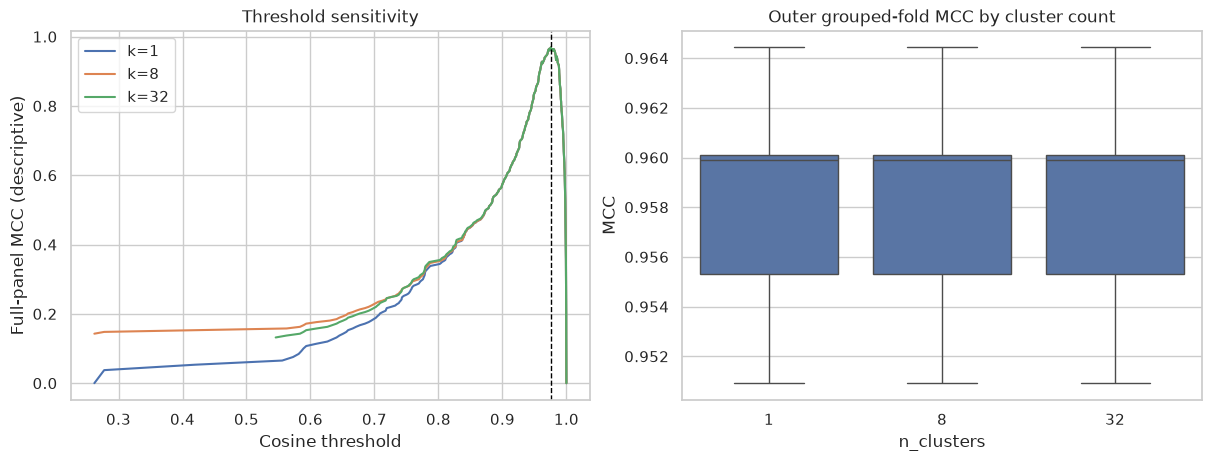

,tp,fp,tn,fn,precision,recall,f1,mcc
descriptive full-panel fit,183,5,276,2,0.973404,0.989189,0.981233,0.968799


,pair_key,label,cosine,same_cluster,error,left_question,right_question
457,e3437c0fc0ad76ff6fa91b740c8ea64310de2fc6efdeb67390d3a1c60f57cb04::eea2e43b33128a0aab3d43e5d6ef2f...,duplicate,0.973894,True,FN,O sistema de tarifação de energia elétrica funciona com base em três bandeiras. Na bandeira verd...,O sistema de tarifação de energia elétrica funciona com base em três bandeiras. Na bandeira verd...
345,83c0debb991a75060ad392ee1332bf433d21f57821f32043687538ff3e1501c7::e69fac49738a27cb8b21f2d0ef3226...,duplicate,0.961699,True,FN,"Em relação à aplicação adequada das técnicas de Inteligência Artificial, avalie as afirmações a ...","Em relação à aplicação adequada das técnicas de Inteligência Artificial, avalie as afirmações a ..."
244,52e377dc32e1a3935888d39f631f3221f198e44e7cbffc82afa322a44e8162dc::63b8fbc566103be2d2e007bbdc4815...,related_but_distinct,0.984938,True,FP,Campeonato de lógica O diretor de uma escola precisa selecionar três bons alunos para participar...,Campeonato de lógica O diretor de uma escola precisa selecionar três bons alunos para participar...
337,7edaaf0ad464044c0f6305e61dcb43a5c0afab9ab455c142e0fe9f041e8d8b91::f7636e72b9f07a6b79da8dcff9b528...,related_but_distinct,0.984313,True,FP,"Programa de Recreio Durante os Cursos de Programação da OBI, para os melhores classificados da M...","Programa de Recreio Durante os Cursos de Programação da OBI, para os melhores classificados da M..."
163,3094453fa097da265fed41112e74f7e9e184b282ec5f3b3c5fa55f764622428a::d0d8b192f4b8d1b2c846c1e1ff7f5b...,related_but_distinct,0.983739,True,FP,Rali de Informática O professor de informática da escola inventou uma nova modalidade de competi...,Rali de Informática O professor de informática da escola inventou uma nova modalidade de competi...
308,70ed59f054b329f8b8a32a5f817cb979364f60d1bd86c92728b7688c9d4ae648::e9b0e10229be362e470c2c35db333d...,related_but_distinct,0.979441,True,FP,"Peruas da prefeitura A cada dia, cinco meninas – Fernanda, Giulia, Helena, Joice e Karina – e qu...","Peruas da prefeitura A cada dia, cinco meninas – Fernanda, Giulia, Helena, Joice e Karina – e qu..."
170,35942e0a1362ec7f4b8220eb18e620d8a55e1fd0c4681cc67d4475aea7685490::557cd501c961f144f380045d529d90...,related_but_distinct,0.978431,True,FP,No Restaurante Italiano Sandro sempre que vai ao restaurante italiano põe em sua macarronada no ...,No Restaurante Italiano Sandro sempre que vai ao restaurante italiano põe em sua macarronada no ...


In [7]:
curve_rows = []
for count in CLUSTER_COUNTS:
    for threshold in threshold_grid(pair_cosine, candidate_masks[count]):
        result = metrics(labels, candidate_masks[count] & (pair_cosine >= threshold))
        curve_rows.append({"n_clusters": count, "threshold": threshold, **result})
threshold_curves = pd.DataFrame(curve_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
for count, frame in threshold_curves.groupby("n_clusters"):
    axes[0].plot(frame.threshold, frame.mcc, label=f"k={count}")
axes[0].axvline(selected_threshold, color="black", linestyle="--", linewidth=1)
axes[0].set(xlabel="Cosine threshold", ylabel="Full-panel MCC (descriptive)", title="Threshold sensitivity")
axes[0].legend()
sns.boxplot(data=treatment_metrics, x="n_clusters", y="mcc", ax=axes[1])
axes[1].set(title="Outer grouped-fold MCC by cluster count", xlabel="n_clusters", ylabel="MCC")
fig.savefig(ARTIFACT_ROOT / "calibration.png", dpi=180, bbox_inches="tight")
plt.show()

full_metrics = metrics(labels, selected_prediction)
pair_audit = pairs.assign(cosine=pair_cosine, same_cluster=candidate_masks[selected_clusters], prediction=selected_prediction)
pair_audit["error"] = np.select(
    [labels & ~selected_prediction, ~labels & selected_prediction], ["FN", "FP"], default="",
)
pair_audit.to_parquet(ARTIFACT_ROOT / "pair_audit.parquet", index=False)
display(pd.DataFrame([full_metrics], index=["descriptive full-panel fit"]))
display(pair_audit[pair_audit.error.ne("")][[
    "pair_key", "label", "cosine", "same_cluster", "error", "left_question", "right_question",
]].sort_values(["error", "cosine"], ascending=[True, False]).head(20))


## 5. Final NVIDIA identification and removal

The selected parameters are now passed back to `SemanticDeduplicationWorkflow`, which writes NVIDIA's duplicate-ID files. `TextDuplicatesRemovalWorkflow` then filters a copy of the 837 experimental items. Removal relations are audited separately from pair classification: an unlabeled relation remains unknown, and `max_id` may itself be removed because SemDeDup compares each row to preceding rows rather than only to retained representatives.


In [8]:
from nemo_curator.stages.text.deduplication.removal_workflow import TextDuplicatesRemovalWorkflow

final_run = CACHE_ROOT / "final_semantic"
final_output = ARTIFACT_ROOT / "deduplicated"
final_complete = CACHE_ROOT / "final_complete.json"
if not final_complete.exists():
    if not RUN_COMPUTE:
        raise FileNotFoundError("Missing final NeMo run")
    if ray.is_initialized() or os.environ.get("RAY_ADDRESS"):
        raise RuntimeError("Close the existing Ray session before the final isolated run")
    with RayClient(num_gpus=1, num_cpus=8, include_dashboard=False, object_store_memory=2 * 1024**3):
        started = time.perf_counter()
        final_workflow = SemanticDeduplicationWorkflow(
            input_path=str(embedding_output), output_path=str(final_run / "results"),
            cache_path=str(final_run / "cache"), n_clusters=selected_clusters,
            id_field="id", embedding_field="embeddings", embedding_dim=EMBEDDING_DIMENSION,
            input_filetype="parquet", max_iter=300, tol=1e-4, random_state=SEED,
            fit_data_fraction=None, distance_metric="cosine", which_to_keep="hard",
            pairwise_batch_size=PAIRWISE_BATCH_SIZE, eps=selected_eps, verbose=False,
        )
        final_workflow.run(kmeans_executor=RayActorPoolExecutor(), pairwise_executor=XennaExecutor())
        removal_workflow = TextDuplicatesRemovalWorkflow(
            input_path=str(removal_input), ids_to_remove_path=str(final_run / "results/duplicates"),
            output_path=str(final_output), input_filetype="parquet", id_field="id",
            duplicate_id_field="id", output_filetype="parquet",
            output_fields=["id", "question", "choices"], output_kwargs={"index": False},
            output_mode="overwrite",
        )
        removal_result = removal_workflow.run(executor=XennaExecutor())
        final_seconds = time.perf_counter() - started
    write_json(final_complete, {
        **selection, "seconds": final_seconds,
        "num_duplicates_removed": removal_result.metadata["num_duplicates_removed"],
    })
else:
    final_seconds = json.loads(final_complete.read_text())["seconds"]

removed = parquet_files(final_run / "results/duplicates")
relations = parquet_files(final_run / "cache/pairwise_results")
deduplicated = parquet_files(final_output)
removed_ids = set(removed.id) if len(removed) else set()
expected_removed_ids = set(relations.loc[relations.cosine_sim_score >= selected_threshold, "id"])
assert removed_ids == expected_removed_ids
assert set(deduplicated.id) == set(items.id) - removed_ids
assert len(deduplicated) + len(removed_ids) == len(items)

removal_audit = relations[relations.id.isin(removed_ids)].copy()
removal_audit["max_id_also_removed"] = removal_audit.max_id.isin(removed_ids)
annotated_labels = {
    tuple(sorted((row.left_id, row.right_id))): row.label for row in pairs.itertuples(index=False)
}
removal_audit["annotated_label"] = [
    annotated_labels.get(tuple(sorted((identifier, reference))), "unannotated")
    for identifier, reference in zip(removal_audit.id, removal_audit.max_id, strict=True)
]
if len(removal_audit):
    a = removal_audit.id.map(item_index).to_numpy()
    b = removal_audit.max_id.map(item_index).to_numpy()
    direct = np.einsum("ij,ij->i", embeddings[a], embeddings[b])
    assert np.allclose(removal_audit.cosine_sim_score, direct, atol=2e-5)
    assert (removal_audit.cosine_sim_score >= selected_threshold).all()
removal_audit.to_parquet(ARTIFACT_ROOT / "removal_audit.parquet", index=False)
removed.sort_values("id").to_parquet(ARTIFACT_ROOT / "removed_ids.parquet", index=False)
display(pd.Series({
    "input_items": len(items), "removed_items": len(removed_ids), "retained_items": len(deduplicated),
    "references_also_removed": int(removal_audit.max_id_also_removed.sum()),
    "annotated_removal_relations": int(removal_audit.annotated_label.ne("unannotated").sum()),
    "seconds": final_seconds,
}).to_frame("value"))
display(removal_audit.head(20))


,value
input_items,837.000000
removed_items,218.000000
retained_items,619.000000
references_also_removed,36.000000
annotated_removal_relations,169.000000
seconds,118.931478


,id,max_id,cosine_sim_score,max_id_also_removed,annotated_label
1,7de9a980b6fe6230b58bbee07d010ef4150aa4e9aa5bb5843988586fed8c7b2a,7d95691d8638050ae0ced59588e5615f82a1e7ed5515fa39d39e3ef93da4363f,0.998065,False,duplicate
3,651de9511cab1a1f825082e7e892be71ae9e701c8177ac65b1ef984e54c5bd16,618c20274e77d612cd6dcfaceeb5cb5ca643e1ddcb1de264f0153ebe4da1d8b7,0.998181,False,duplicate
5,5f1ad62fe746e4a0a2aef2ba9f892ca73b9655f27174598ef2406f5a21ad02fe,00f3e3d8c15b999d7a01eb08d9ca11e9f209110485cc4a4f5359e71c4b8ef503,0.995540,False,duplicate
7,ddd773c976edc7c1fa3f52da72902f824d45552f782842f0fb37017b7cedb9ca,1d47e1d6dbaac3494debf3600ef8178b9e6eb74682cb9d093eface829ee62528,0.999497,False,duplicate
9,f2870a1d192aa671c458e3a5ca154d6d9286ba8a78a0d0537ade76e305bf9c0f,db17281d098d476782eea4334d2abe6f8f50ea862d6fa481d4841b265e5c8907,0.994998,False,duplicate
10,c6b7a7d7284969514f72548aa3f9aadbc072937fbd91644095534b308030001f,618c20274e77d612cd6dcfaceeb5cb5ca643e1ddcb1de264f0153ebe4da1d8b7,0.995046,False,duplicate
17,5dbe800443b376b557d509d166cefb557ef7c2ecb5eb5ded941b979a5d85f680,c0e05bb4c72cd7cdf208d0a86e4e89203e80dd7f895b88b12a0883859d4dea3f,0.998698,False,duplicate
19,193b0f089c007b4c19c983a413d74bc37fbcb42dd59c8bde9890bbc4b5a9979b,a200c45743f844b8a2dc447f2983c60305df397d36d60a73dbecd22153277b04,0.991766,False,duplicate
22,c91fa55cc10b28c300ae02eb6ab78788ee69cf22d95b98d4a1e3e6a1005952ea,4c1d4b4e1307464a561061951cf6321d1a95ea93648b98dce7dae509d24b8e2a,0.997980,False,duplicate
31,9ec10e22c89456384f6f1c2da3a537f770369a759eed6df10356c5f29f3880b9,ab10ca7a4d726973e0bfcc8bca0c76b073238a2950060fe47f553dc65c60f1ff,0.999434,False,duplicate


## 6. Traceability and conclusion


In [9]:
mean_outer = repeat_metrics[["mcc", "precision", "recall", "f1"]].mean()
std_outer = repeat_metrics[["mcc", "precision", "recall", "f1"]].std()
analysis = f"""# NVIDIA SemDeDup with Octen via vLLM

Run: {datetime.now(timezone.utc).isoformat()}  
Panel: {len(pairs)} annotated pairs, {len(items)} unique items, {pairs.group_id.nunique()} grouped components.

## Selected configuration

- Model: `{MODEL_ID}` at `{MODEL_REVISION}`
- Embeddings: `VLLMEmbeddingModelStage`, last-token pooling, normalized 4096-dimensional vectors
- `n_clusters={selected_clusters}`, `which_to_keep=hard`
- cosine threshold: `{selected_threshold:.9f}`; `eps={selected_eps:.9f}`

The nested grouped procedure achieved mean outer MCC {mean_outer.mcc:.3f} ± {std_outer.mcc:.3f},
precision {mean_outer.precision:.1%}, recall {mean_outer.recall:.1%}, and F1 {mean_outer.f1:.1%}.
The final full-panel fit is descriptive: TP={full_metrics['tp']}, FP={full_metrics['fp']},
TN={full_metrics['tn']}, FN={full_metrics['fn']}. The NVIDIA removal workflow marked
{len(removed_ids)} of {len(items)} experimental items for removal.

## Limits

The evaluation is transductive because unsupervised embeddings and clusters use all panel texts.
The 466 pairs were enriched through lexical retrieval and labeled by an LLM; only two negatives are
labeled `distinct`. Results therefore select the best setting among 1, 8, and 32 clusters for this
panel and do not establish population-wide optimality. Unannotated removal relations are not counted
as correct or incorrect.
"""
(ARTIFACT_ROOT / "analysis.md").write_text(analysis, encoding="utf-8")

artifact_paths = [
    ARTIFACT_ROOT / "analysis.md", ARTIFACT_ROOT / "calibration.png",
    ARTIFACT_ROOT / "cluster_diagnostics.csv", ARTIFACT_ROOT / "final_inner_ranking.parquet",
    ARTIFACT_ROOT / "outer_results.parquet", ARTIFACT_ROOT / "pair_audit.parquet",
    ARTIFACT_ROOT / "removal_audit.parquet", ARTIFACT_ROOT / "removed_ids.parquet",
    ARTIFACT_ROOT / "selected_configuration.json",
]
manifest = {
    "run_id": RUN_ID, "spec": SPEC, "selection": selection,
    "embedding": embedding_info, "input_pairs": len(pairs), "unique_items": len(items),
    "removed_items": len(removed_ids), "retained_items": len(deduplicated),
    "mean_outer_metrics": {key: float(value) for key, value in mean_outer.items()},
    "std_outer_metrics": {key: float(value) for key, value in std_outer.items()},
    "artifacts_sha256": {path.name: file_sha256(path) for path in artifact_paths},
    "python_version": platform.python_version(), "created_at": datetime.now(timezone.utc).isoformat(),
}
write_json(ARTIFACT_ROOT / "manifest.json", manifest)
display(Markdown(analysis))


# NVIDIA SemDeDup with Octen via vLLM

Run: 2026-09-29T19:31:44.250347+00:00  
Panel: 466 annotated pairs, 837 unique items, 373 grouped components.

## Selected configuration

- Model: `Octen/Octen-Embedding-8B` at `5adcfa292e712091dfc30f0e97f0b2282e6cc66c`
- Embeddings: `VLLMEmbeddingModelStage`, last-token pooling, normalized 4096-dimensional vectors
- `n_clusters=1`, `which_to_keep=hard`
- cosine threshold: `0.975506753`; `eps=0.024493247`

The nested grouped procedure achieved mean outer MCC 0.958 ± 0.004,
precision 96.6%, recall 98.4%, and F1 97.5%.
The final full-panel fit is descriptive: TP=183, FP=5,
TN=276, FN=2. The NVIDIA removal workflow marked
218 of 837 experimental items for removal.

## Limits

The evaluation is transductive because unsupervised embeddings and clusters use all panel texts.
The 466 pairs were enriched through lexical retrieval and labeled by an LLM; only two negatives are
labeled `distinct`. Results therefore select the best setting among 1, 8, and 32 clusters for this
panel and do not establish population-wide optimality. Unannotated removal relations are not counted
as correct or incorrect.
